In [29]:
# standard python imports
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import scipy as sp

# tidy3d imports
import tidy3d as td
import tidy3d.web as web
from tidy3d.plugins.resonance import ResonanceFinder
from tidy3d import material_library

web.configure(apikey="GoMnpjx6Gxf00bAc6wa2oPoqrR3mbWeYuuyi3aTPF94dR1kO")
td.config.logging_level = "ERROR"

API key configured successfully.


In [30]:
rng = np.random.default_rng(12345)

<Axes: title={'center': 'cross section at z=0.00 (μm)'}, xlabel='x (μm)', ylabel='y (μm)'>

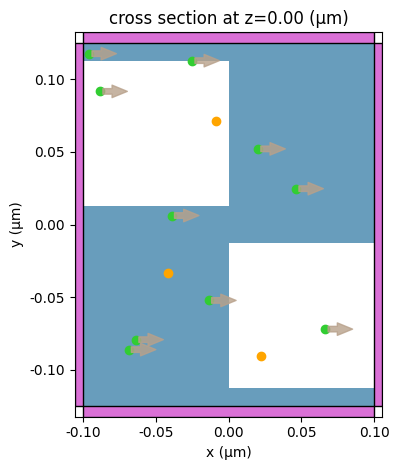

In [31]:
import tidy3d as td
import numpy as np

def create_1cell_sim(wl_target=1.55, period_x=0.200, period_y=0.250, a=0.100, h_si=0.220, k_y=10.0):
    freq0 = td.C_0 / wl_target    # Target frequency (Hz)
    fwidth = freq0 * 0.2          # Bandwidth for the dipole pulse

    padding_z = 1.5               # Top/bottom oxide cladding thickness (um)
    mat_si = material_library['cSi']['Palik_Lossless']
    mat_sio2 = material_library['SiO2']['Palik_Lossless']

    si_block = td.Structure(
        geometry=td.Box(
            center=(0, 0, 0),
            size=(td.inf, td.inf, h_si)
        ),
        medium=mat_si,
        name="Si_Core"
    )

    hole_1 = td.Structure(
        geometry=td.Box(
            center=(-period_x/4, period_y/4, 0),
            size=(a, a, td.inf)
        ),
        medium=mat_sio2,
        name="Hole_TopLeft"
    )

    hole_2 = td.Structure(
        geometry=td.Box(
            center=(period_x/4, -period_y/4, 0),
            size=(a, a, td.inf)
        ),
        medium=mat_sio2,
        name="Hole_BottomRight"
    )

    geometry = [si_block, hole_1, hole_2]

    sources = []
    num_dipoles = 10
    polarization = "Ex"

    # Randomly scatter dipoles inside the silicon core
    np.random.seed(42) # For reproducibility
    for i in range(num_dipoles):
        x_pos = np.random.uniform(-period_x/2, period_x/2)
        y_pos = np.random.uniform(-period_y/2, period_y/2)
        
        dipole = td.PointDipole(
            center=(x_pos, y_pos, 0),
            source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
            polarization=polarization,
            name=f"dipole_{i}"
        )
        sources.append(dipole)

    monitors = []
    # Place a few time monitors to record the ringdown
    for i in range(3):
        x_pos = np.random.uniform(-period_x/2, period_x/2)
        y_pos = np.random.uniform(-period_y/2, period_y/2)
        
        t_monitor = td.FieldTimeMonitor(
            center=(x_pos, y_pos, 0),
            size=(0, 0, 0),
            interval=1,
            start=1e-12,
            name=f"time_mon_{i}"
        )
        monitors.append(t_monitor)

    sim_size = (period_x, period_y, h_si + 2*padding_z)

    sim = td.Simulation(
        size=sim_size,
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=15), # Let subpixel smoothing work
        structures=geometry,
        sources=sources,
        monitors=monitors,
        run_time=5e-12,
        shutoff=0,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.bloch(bloch_vec=0),        # 0 phase shift in X (infinite width)
            y=td.Boundary.bloch(bloch_vec=k_y),      # Target phase shift in Y
            z=td.Boundary.pml()                      # PML on top/bottom
        ),
        medium=mat_sio2 # Background material is oxide
    )
    return sim


# Plot the geometry to verify the checkerboard layout
sim = create_1cell_sim()
sim.plot(z=0)

In [5]:
sim.plot_3d()

In [21]:
k_y_vals = np.linspace(11.0, 12.2, 5)

simulations = {}

for k in k_y_vals:
    sim_name = f"1cell_ky_{k:.4f}"
    simulations[sim_name] = create_1cell_sim(k_y=k)

batch = web.Batch(simulations=simulations, folder_name="mmi_swg/1cell_test/ky_sweep/", verbose=True)
batch.estimate_cost()

00:52:32 SE Asia Standard Time WARNING: Structure at 'structures[1]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

                               WARNING: Suppressed 1 WARNING message.           

                               WARNING: Structure at 'structures[1]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

                               WARNING: Suppressed 1 WARNING message.           

                               WARNING: Structure at 'structures[1]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

...

                               WARNING: Suppressed 1 WARNING message.           

                               WARNING: Structure at 'structures[1]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

00:52:33 SE Asia Standard Time WARNING: Suppressed 1 WARNING message.           

00:52:52 SE Asia Standard Time Maximum FlexCredit cost: 0.125 for the whole     
                               batch.

0.125

In [22]:
batch_results = batch.run(path_dir="data/mmi_swg/1cell_test/ky_sweep/")

Output()

00:52:53 SE Asia Standard Time WARNING: Structure at 'structures[1]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

                               WARNING: Suppressed 1 WARNING message.           

                               WARNING: Structure at 'structures[1]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

                               WARNING: Suppressed 1 WARNING message.           

...

                               WARNING: Structure at 'structures[1]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

                               WARNING: Suppressed 1 WARNING message.           

                               WARNING: Structure at 'structures[1]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

                               WARNING: Suppressed 1 WARNING message.           

Output()

In [ ]:
# ==========================================
# 1. EXTRACT DATA FROM BATCH
# ==========================================
# Look around 1550nm
freq0 = td.C_0 / 1.55 
res_finder = ResonanceFinder(freq_window=(freq0 * 0.7, freq0 * 1.3))

extracted_k = []
extracted_f = []

for sim_name, sim_data in batch_results.items():
    k_y_current = float(sim_name.split("_")[2])
    
    time_signals = [sim_data[f"time_mon_{i}"] for i in range(3)]
    
    df_res = res_finder.run(signals=time_signals).to_dataframe().reset_index()
    
    if not df_res.empty:
            df_clean = df_res[df_res['freq'] > 100e12]
            
            if not df_clean.empty:
                dominant_mode = df_clean.sort_values(by="amplitude", ascending=False).iloc[0]
                f_res = dominant_mode["freq"]
                
                extracted_k.append(k_y_current)
                extracted_f.append(f_res)
                print(f"k_y = {k_y_current:.4f} rad/um  -->  Resonates at: {f_res/1e12:.2f} THz")
            else:
                print(f"k_y = {k_y_current:.4f} rad/um  -->  No valid high-frequency modes found.")

if len(extracted_f) > 1:
    interp_func = sp.interpolate.interp1d(extracted_f, extracted_k, kind='linear', fill_value="extrapolate")
    exact_ky_1550 = interp_func(freq0)
    final_neq = (exact_ky_1550 * td.C_0) / (2 * np.pi * freq0)
    
    print("\n" + "="*40)
    print("🎯 EXACT SWG INDEX AT 1550nm 🎯")
    print("="*40)
    print(f"Interpolated k_y:  {exact_ky_1550:.4f} rad/um")
    print(f"True 3D n_eq (TE): {final_neq:.4f}")
else:
    print("Not enough data points to interpolate.")

k_y = 11.0000 rad/um  -->  No valid high-frequency modes found.
k_y = 11.3000 rad/um  -->  Resonates at: 182.73 THz
k_y = 11.6000 rad/um  -->  Resonates at: 228.83 THz
k_y = 11.9000 rad/um  -->  No valid high-frequency modes found.
k_y = 12.2000 rad/um  -->  Resonates at: 132.97 THz

🎯 EXACT SWG INDEX AT 1550nm 🎯
Interpolated k_y:  11.3695 rad/um
True 3D n_eq (TE): 2.8047
